# Simple Rotation

In [4]:
import sympy as sp
import sympy.physics.mechanics as mech
from sympy.physics.mechanics import *
import matplotlib.pyplot as plt

init_vprinting()

In [5]:
# Define symbols
theta = dynamicsymbols('theta')
t = sp.symbols('t')

# Define parameters
m, l, g = sp.symbols('m l g')


In [6]:
# Define Reference Frames
N = ReferenceFrame('N')  # Inertial frame
# dcmA rotates from N to A about N.z by angle theta
# Rotating frame A
# A = ReferenceFrame('A')  # Rotating frame
# dcmA = sp.Matrix([[sp.cos(theta), -sp.sin(theta), 0],
#                      [sp.sin(theta),  sp.cos(theta), 0],
#                      [0,              0,             1]])
# A.orient_explicit(N, dcmA)  # Rotate A about N.z by theta
#   --- OR ---
A = N.orientnew('A', 'Axis', [theta, N.z])  # Rotate A about N.z by theta

In [7]:
# Create points of interest

O = Point('O')  # Origin point
O.set_vel(N, 0)  # Origin point

P = O.locatenew('P', l * A.x + l* A.y)  # Point P at distance l along A.x from O

In [8]:
# Now, let's ask SymPy for the angular velocity of frame A in frame N
# This is a fundamental quantity: ω_A_in_N or ^Nω^A
omega_A_in_N = A.ang_vel_in(N)

omega_A_in_N

print("Velocity (v_P_in_N):")
display(P.vel(N))

print("\nAcceleration (a_P_in_N):")
display(P.acc(N))

Velocity (v_P_in_N):



Acceleration (a_P_in_N):


# 2 DOF Arm

Using Lagrangian Mechanics and Sympy to find the EOMS for a double pendulum

x is left and right

y is in and out

z is up and down


## Find EOMS

In [1]:
import sympy as sp
from sympy import *
from sympy.physics.mechanics import *
import matplotlib.pyplot as plt

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

init_printing(use_latex=True)

In [16]:
# Define generalized coordinates and their derivatives
theta1, theta2 = dynamicsymbols('theta1 theta2')
dtheta1, dtheta2 = dynamicsymbols('theta1 theta2', 1)

# Define symbols (Both arms are the same)
m1, L1, m2, L2, g= sp.symbols('m1 L1 m2 L2 g')
t = sp.symbols('t')

# Inertia symbols
# Jxx, Jyy, Jzz = sp.symbols('Jxx Jyy Jzz')

## Absolute Coordinates

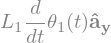

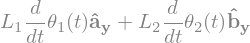

In [22]:
# Define Reference Frames
N = ReferenceFrame('N')  # Inertial frame
A = N.orientnew('A', 'Axis', [theta1, N.z])  # Rotating frame 1
B = N.orientnew('B', 'Axis', [theta2, N.z])  # Rotating frame 2

# Set angular velocities
A.set_ang_vel(N, dtheta1 * N.z)
B.set_ang_vel(N, dtheta2 * N.z)

# Create points of interest
O = Point('O')  # Origin point
P1 = O.locatenew('P1', L1 * A.x)  # End point first arm
P2 = P1.locatenew('P2', L2 * B.x)  # End point second arm


O.set_vel(N, 0)  # Origin point
P1.v2pt_theory(O, N, A)  # Velocity of P in N using v2pt_theory
P2.v2pt_theory(P1, N, B)  # Velocity of P2 in N using v2pt_theory



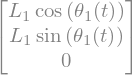

In [25]:
P1.pos_from(O).express(N).simplify().to_matrix(N)
P2.pos_from(O).express(N).simplify()

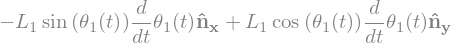

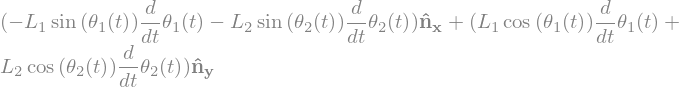

In [24]:
P1.vel(N).express(N).simplify()
P2.vel(N).express(N).simplify()

In [ ]:
# Create Rigid Bodies
I1 = inertia(A, Jxx, Jyy, Jzz)  # Inertia tensor for first arm
I2 = inertia(B, Jxx, Jyy, Jzz)  # Inertia tensor for second arm

Arm1 = RigidBody('Body1', G1, A, m, (I1, G1))
Arm2 = RigidBody('Body2', G2, B, m, (I2, G2))

In [41]:
# Potential Energies
V1 = -m * g * dot(G1.pos_from(O), N.z)
V2 = -m * g * dot(G2.pos_from(O), N.z)

# Lagrangian
L = Lagrangian(N, Arm1, Arm2)
LM = LagrangesMethod(L, [theta1, theta2])
equations = LM.form_lagranges_equations()
equations.simplify()
display(equations)

⎡                                                                              ↪
⎢                                 4            2                               ↪
⎢       2              ⎛d        ⎞  ⎛d        ⎞                                ↪
⎢  5⋅Jyy ⋅m⋅sin(θ₂(t))⋅⎜──(θ₁(t))⎟ ⋅⎜──(θ₂(t))⎟                                ↪
⎢                      ⎝dt       ⎠  ⎝dt       ⎠         2              ⎛d      ↪
⎢- ───────────────────────────────────────────── - 4⋅Jyy ⋅m⋅sin(θ₂(t))⋅⎜──(θ₁( ↪
⎢                        2                                             ⎝dt     ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                           

In [ ]:
# 6. Solve for accelerations (q double dot)
# equivalent to: mass_matrix_inv * forcing_vector
sol = LM.rhs() 

mprint(sol)

# Find jacobian for mass matrix

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   theta1'],
[                                                                                                                                                                                                                                                                                                                                                                                                                

## Simulate Motion

In [ ]:
params = [l, m, g, Iz]
# The state vector is [q1, q2, q1d, q2d]
state_sym = [q1, q2, q1d, q2d]

# Create a fast binary function from the symbolic solution
# modules='numpy' makes it use fast numpy math instead of sympy math
eom_func = lambdify((state_sym, params), sol, modules='numpy')
